In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

In [3]:
nodes = pd.read_pickle("../5-s288c-nodes-final-per-node.pkl")

In [4]:
# APPLY FILTERS

# remove nodes with no sequence information from SGD
filtered_nodes = nodes[~nodes["sequence"].isna()]
print (f"Number of nodes with sequence information: {filtered_nodes.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = nodes[nodes["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
filtered_nodes = filtered_nodes[filtered_nodes["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {filtered_nodes.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
filtered_nodes = filtered_nodes[filtered_nodes["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {filtered_nodes.shape[0]}")

Number of nodes with sequence information: 3876
Number of nodes without sequence information: 51
Number of nodes with sequence & structure information: 3867
Number of nodes with sequence, structure, and matching information between the two: 3859


In [11]:
column_names = list(filtered_nodes.columns)
print (column_names)

['node', '_wkshell', 'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality', 'CentralityCosDist_rank', 'CentralityCosDist_similarity_score', 'has_verified_sequence', 'sequence', 'UniProtKB-AC', 'mask', 'DeepTMHMM_trimmed_sequence', 'DeepTMHMM_class', 'cleavage_site_start', 'signalP_trimmed_sequence', 'ProteinName', 'GO_terms', 'GO_terms_human_readable', 'localization_keywords', 'parsed_functions', 'parsed_PTMs', 'ptm_bronze', 'ptm_gold', 'ptm_silver', 'disorder_predictions', 'disorder_fraction', 'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_d

### Perform some new analyses based on the current pd.DataFrame

In [23]:
# compute the 90th percentile
threshold = filtered_nodes["degree_centrality"].quantile(0.90)

# filter by this value
top10 = filtered_nodes[filtered_nodes["degree_centrality"] >= threshold]
bot90 = filtered_nodes[filtered_nodes["degree_centrality"] < threshold]

# add column with boolean mask for top 10 by degree centrality
filtered_nodes["is_top10"] = filtered_nodes["degree_centrality"] >= threshold

print(top10.info())
print(bot90.info())

<class 'pandas.core.frame.DataFrame'>
Index: 399 entries, 1 to 3911
Columns: 204 entries, node to Y2H_CentralityCosDist_similarity_score
dtypes: bool(2), float64(100), int64(39), object(63)
memory usage: 633.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 3460 entries, 0 to 3926
Columns: 204 entries, node to Y2H_CentralityCosDist_similarity_score
dtypes: bool(2), float64(100), int64(39), object(63)
memory usage: 5.4+ MB
None


#### Protein abundance

/tmp/ipykernel_825968/1633302246.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  b = ax.boxplot(


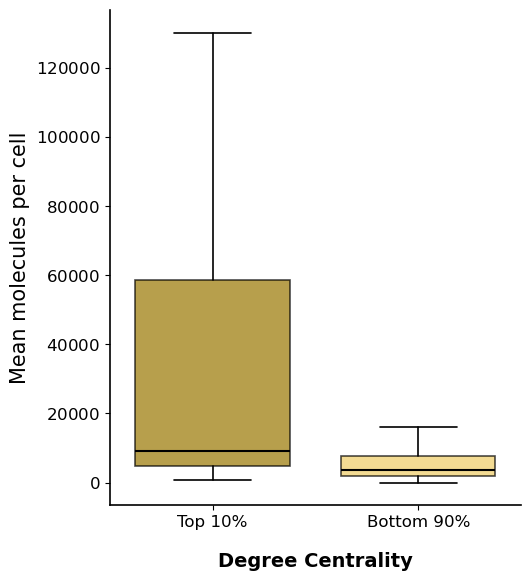

Mann-Whitney U on 'Mean molecules per cell': U = 1.05e+06, p = 7.7e-67

     Group   Min       Max     Range         Mean  Median   Mode      Std Dev
   Top 10% 716.0 1392599.0 1391883.0 46741.553885  9170.0 4463.0 121951.95082
Bottom 90%   7.0 1371127.0 1371120.0 10681.687427  3516.5 2016.0  41965.23644


In [21]:
# prep data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ---------- 0) Choose the column (handles either space or underscore naming) ----------
FEATURE = None
for cand in ["Mean molecules per cell", "Mean_molecules_per_cell"]:
    if cand in top10.columns and cand in bot90.columns:
        FEATURE = cand
        break
if FEATURE is None:
    raise ValueError("Couldn't find 'Mean molecules per cell' (or underscore variant) in both dataframes.")

# ---------- 1) Style (mirrors your preferred settings) ----------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
sns.set_style('white')

# ---------- 2) Prepare data ----------
data = [
    pd.to_numeric(top10[FEATURE], errors='coerce').dropna(),
    pd.to_numeric(bot90[FEATURE], errors='coerce').dropna()
]
group_labels = ["Top 10%", "Bottom 90%"]
group_colors = ['#997700', '#EECC66']  # your palette

# ---------- 3) Plot ----------
fig, ax = plt.subplots(figsize=(5.5, 6))
b = ax.boxplot(
    data,
    patch_artist=True,
    labels=group_labels,
    showfliers=False,
    widths=0.75,
    boxprops=dict(linewidth=1.2, color='black'),
    medianprops=dict(linewidth=1.5, color='black'),
    whiskerprops=dict(linewidth=1.2, color='black'),
    capprops=dict(linewidth=1.2, color='black')
)

# Fill box colors with transparency
for patch, color in zip(b['boxes'], group_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Axes labels/ticks
ax.set_ylabel(FEATURE.replace('_', ' '), fontsize=15, color='black')
ax.set_xlabel("Degree Centrality", fontsize=14, color='black', fontweight='bold', labelpad=16)
ax.tick_params(axis='both', labelsize=12, colors='black')

# Keep only left & bottom spines visible and clean
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.grid(False)

# Optional: log-scale y if abundances are heavy-tailed
# ax.set_yscale('log')

plt.tight_layout()
plt.show()

# ---------- 4) Mann–Whitney U test (printed cleanly) ----------
if len(data[0]) > 0 and len(data[1]) > 0:
    stat, pval = mannwhitneyu(data[0], data[1], alternative='two-sided')
    print(f"Mann-Whitney U on '{FEATURE}': U = {stat:.2e}, p = {pval:.2g}\n")
else:
    print("Not enough data for Mann-Whitney U test.\n")


def summarize(df, label):
    series = df["Mean molecules per cell"].dropna()
    return {
        "Group": label,
        "Min": series.min(),
        "Max": series.max(),
        "Range": series.max() - series.min(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Mode": series.mode().iloc[0] if not series.mode().empty else None,
        "Std Dev": series.std()
    }

summary_df = pd.DataFrame([
    summarize(top10, "Top 10%"),
    summarize(bot90, "Bottom 90%")
])

print(summary_df.to_string(index=False))

#### Refoldability

In [27]:
# create a 2x2 contingency table with columns = Yes/No non-refoldable
#                                 and rows    = Yes/No top 10%

# list of columns you want to test
refold_cols = [
    'nonrefoldable_any',
    'nonrefoldable_all',
    'nonrefoldable_1min_any',
    'nonrefoldable_1min_all',
    'nonrefoldable_5min_any',
    'nonrefoldable_5min_all',
    'nonrefoldable_120min_any',
    'nonrefoldable_120min_all'
]

def bh_fdr(pvals):
    try:
        from statsmodels.stats.multitest import multipletests
        _, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
        return p_adj
    except Exception:
        # Manual BH as fallback
        import numpy as np
        pvals = np.asarray(pvals, dtype=float)
        n = pvals.size
        order = np.argsort(pvals)
        ranked = pvals[order]
        adj = ranked * n / (np.arange(1, n+1))
        # enforce monotonicity from right to left
        adj = np.minimum.accumulate(adj[::-1])[::-1]
        # cap at 1
        adj = np.clip(adj, 0, 1)
        out = np.empty_like(adj)
        out[order] = adj
        return out

# ---- Main loop: build tables, run Fisher, collect results ----
rows = []
for col in refold_cols:
    if col not in filtered_nodes.columns:
        continue  # skip missing columns

    df = filtered_nodes.dropna(subset=[col, "is_top10"]).copy()

    # enforce binary (in case values are floats/strings)
    x = (df[col].astype(float).round().astype(int) == 1)
    top = df["is_top10"].astype(bool)

    a = ( top &  x).sum()  # Top10 & Nonrefoldable=1
    b = ( top & ~x).sum()  # Top10 & Nonrefoldable=0
    c = (~top &  x).sum()  # NotTop10 & Nonrefoldable=1
    d = (~top & ~x).sum()  # NotTop10 & Nonrefoldable=0

    table = [[a, b], [c, d]]

    # Handle zero rows/cols gracefully (Fisher expects non-negative ints; zeros are fine)
    odds_ratio, p = fisher_exact(table, alternative="two-sided")

    rows.append({
        "feature": col,
        "a": int(a), "b": int(b), "c": int(c), "d": int(d),
        "odds_ratio": float(odds_ratio),
        "p_value": float(p)
    })

results = pd.DataFrame(rows)

# If nothing computed (e.g., missing columns), stop early
if results.empty:
    print("No valid columns found or no rows after dropping NAs.")
else:
    # ---- Apply BH FDR ----
    results["p_fdr"] = bh_fdr(results["p_value"].values)
    results["significant_0.05"] = results["p_fdr"] < 0.05

    # ---- Sort and print summary ----
    results_sorted = results.sort_values("p_fdr", ascending=True)

    # Compact print
    display_cols = ["feature", "a","b","c","d", "odds_ratio", "p_value", "p_fdr", "significant_0.05"]
    print(results_sorted[display_cols].to_string(index=False))

    # Optional: save to CSV
    # results_sorted.to_csv("fisher_refoldability_top10_results.csv", index=False)

                 feature   a   b   c    d  odds_ratio  p_value    p_fdr  significant_0.05
nonrefoldable_120min_any  64 173 487  924    0.701903 0.025468 0.172816             False
nonrefoldable_120min_all  17 220 164 1247    0.587555 0.043204 0.172816             False
  nonrefoldable_1min_all  23 214 192 1219    0.682365 0.117347 0.312926             False
  nonrefoldable_5min_all  15 222 130 1281    0.665800 0.172530 0.345059             False
       nonrefoldable_all  11 226  93 1318    0.689790 0.312021 0.499234             False
       nonrefoldable_any 103 134 645  766    0.912854 0.526672 0.616027             False
  nonrefoldable_1min_any  90 147 561  850    0.927644 0.616027 0.616027             False
  nonrefoldable_5min_any  79 158 497  914    0.919517 0.606658 0.616027             False


#### Protein entanglement

In [28]:
# Columns of interest
entanglement_cols = ["AF2_contains_entanglement", "exp_contains_entanglement"]

# Helper: Benjamini–Hochberg
def bh_fdr(pvals):
    try:
        from statsmodels.stats.multitest import multipletests
        _, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
        return p_adj
    except Exception:
        import numpy as np
        pvals = np.asarray(pvals, dtype=float)
        n = pvals.size
        order = np.argsort(pvals)
        ranked = pvals[order]
        adj = ranked * n / (np.arange(1, n+1))
        adj = np.minimum.accumulate(adj[::-1])[::-1]
        adj = np.clip(adj, 0, 1)
        out = np.empty_like(adj)
        out[order] = adj
        return out

# Run Fisher’s exact tests
rows = []
for col in entanglement_cols:
    if col not in filtered_nodes.columns:
        continue

    df = filtered_nodes.dropna(subset=[col, "is_top10"]).copy()

    x = (df[col].astype(float).round().astype(int) == 1)
    top = df["is_top10"].astype(bool)

    a = ( top &  x).sum()   # Top10 & entanglement=1
    b = ( top & ~x).sum()   # Top10 & entanglement=0
    c = (~top &  x).sum()   # NotTop10 & entanglement=1
    d = (~top & ~x).sum()   # NotTop10 & entanglement=0

    table = [[a, b], [c, d]]
    odds_ratio, p = fisher_exact(table, alternative="two-sided")

    rows.append({
        "feature": col,
        "a": int(a), "b": int(b), "c": int(c), "d": int(d),
        "odds_ratio": float(odds_ratio),
        "p_value": float(p)
    })

results = pd.DataFrame(rows)

if not results.empty:
    results["p_fdr"] = bh_fdr(results["p_value"].values)
    results["significant_0.05"] = results["p_fdr"] < 0.05

    print(results.to_string(index=False))
else:
    print("No valid entanglement columns found.")

                  feature   a   b    c    d  odds_ratio  p_value    p_fdr  significant_0.05
AF2_contains_entanglement 246 153 2313 1147    0.797318 0.038634 0.077269             False
exp_contains_entanglement  64  52  371  380    1.260626 0.272814 0.272814             False


#### Oligomerization state

In [29]:
# Columns of interest (oligomer/complex states)
oligomer_cols = [
    'homodimer', 'homotrimer', 'homotetramer',
    'heterodimer', 'heterotrimer', 'heterotetramer',
    'heteropentamer', 'heterohexamer', 'heteroheptamer',
    'heterooctamer', 'heterononamer', 'heterodecamer',
    'in_complex'
]

# Helper: Benjamini–Hochberg
def bh_fdr(pvals):
    try:
        from statsmodels.stats.multitest import multipletests
        _, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
        return p_adj
    except Exception:
        import numpy as np
        pvals = np.asarray(pvals, dtype=float)
        n = pvals.size
        order = np.argsort(pvals)
        ranked = pvals[order]
        adj = ranked * n / (np.arange(1, n+1))
        adj = np.minimum.accumulate(adj[::-1])[::-1]
        adj = np.clip(adj, 0, 1)
        out = np.empty_like(adj)
        out[order] = adj
        return out

# Run Fisher’s exact tests
rows = []
for col in oligomer_cols:
    if col not in filtered_nodes.columns:
        continue

    df = filtered_nodes.dropna(subset=[col, "is_top10"]).copy()

    x = (df[col].astype(float).round().astype(int) == 1)
    top = df["is_top10"].astype(bool)

    a = ( top &  x).sum()   # Top10 & oligomer=1
    b = ( top & ~x).sum()   # Top10 & oligomer=0
    c = (~top &  x).sum()   # NotTop10 & oligomer=1
    d = (~top & ~x).sum()   # NotTop10 & oligomer=0

    table = [[a, b], [c, d]]
    odds_ratio, p = fisher_exact(table, alternative="two-sided")

    rows.append({
        "feature": col,
        "a": int(a), "b": int(b), "c": int(c), "d": int(d),
        "odds_ratio": float(odds_ratio),
        "p_value": float(p)
    })

results = pd.DataFrame(rows)

if not results.empty:
    results["p_fdr"] = bh_fdr(results["p_value"].values)
    results["significant_0.05"] = results["p_fdr"] < 0.05

    # Print nicely
    print(results.sort_values("p_fdr")[["feature","a","b","c","d","odds_ratio","p_value","p_fdr","significant_0.05"]].to_string(index=False))
else:
    print("No valid oligomer/complex columns found.")

       feature   a   b    c    d  odds_ratio  p_value    p_fdr  significant_0.05
 heterooctamer  14 385   24 3436    5.206061 0.000012 0.000156              True
    in_complex 207 192 1430 2030    1.530485 0.000072 0.000470              True
heteroheptamer  13 386   30 3430    3.850604 0.000255 0.001106              True
 heterodecamer  12 387   31 3429    3.429857 0.000982 0.003191              True
heterotetramer   3 396  111 3349    0.228569 0.002759 0.007174              True
heteropentamer   1 398   48 3412    0.178601 0.056543 0.122510             False
  heterotrimer   2 397   59 3401    0.290398 0.085865 0.159464             False
 heterohexamer   3 396   45 3415    0.574916 0.476115 0.773687             False
 heterononamer   0 399    9 3451    0.000000 0.610876 0.844134             False
     homodimer   2 397   12 3448    1.447523 0.649334 0.844134             False
   heterodimer  12 387  115 3345    0.901921 0.882120 1.000000             False
    homotrimer   0 399    1 

#### Chaperone interactions

In [32]:
# 'interacting_chaperones', 'interacting_chaperone_info'

filtered_nodes["interacts_with_chaperone"] = filtered_nodes["interacting_chaperones"].apply(
    lambda x: 1 if len(x) >0 else 0
)

df = filtered_nodes.dropna(subset=["is_top10", "interacts_with_chaperone"]).copy()

x = df["interacts_with_chaperone"].astype(int)   # 1 = interacts, 0 = no interaction
top = df["is_top10"].astype(bool)

a = ( top &  (x == 1)).sum()   # Top10 & interacts
b = ( top &  (x == 0)).sum()   # Top10 & no interaction
c = (~top & (x == 1)).sum()    # NotTop10 & interacts
d = (~top & (x == 0)).sum()    # NotTop10 & no interaction

table = [[a, b],
         [c, d]]

odds_ratio, pval = fisher_exact(table, alternative="two-sided")

# Build summary DataFrame
summary = pd.DataFrame([{
    "feature": "interacts_with_chaperone",
    "a": int(a), "b": int(b), "c": int(c), "d": int(d),
    "odds_ratio": float(odds_ratio),
    "p_value": float(pval)
}])

print(summary.to_string(index=False))

                 feature   a   b   c    d  odds_ratio      p_value
interacts_with_chaperone 122 277 419 3041    3.196557 1.198361e-19


#### Essentiality

In [33]:
df = filtered_nodes.dropna(subset=["is_top10", "essential"]).copy()

x = df["essential"].astype(int)   # 1 = interacts, 0 = no interaction
top = df["is_top10"].astype(bool)

a = ( top &  (x == 1)).sum()   # Top10 & interacts
b = ( top &  (x == 0)).sum()   # Top10 & no interaction
c = (~top & (x == 1)).sum()    # NotTop10 & interacts
d = (~top & (x == 0)).sum()    # NotTop10 & no interaction

table = [[a, b],
         [c, d]]

odds_ratio, pval = fisher_exact(table, alternative="two-sided")

# Build summary DataFrame
summary = pd.DataFrame([{
    "feature": "essential",
    "a": int(a), "b": int(b), "c": int(c), "d": int(d),
    "odds_ratio": float(odds_ratio),
    "p_value": float(pval)
}])

print(summary.to_string(index=False))

  feature   a   b   c    d  odds_ratio      p_value
essential 174 225 840 2620    2.412063 2.379327e-15
